# Exercícios — Calibração de Probabilidades

**Tema:** Avaliação e Validação de Modelos › Calibração de Probabilidades

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(656)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR, CINZA = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100", "#5A5A5A"
print("ambiente pronto")

ambiente pronto


---
## Dataset de trabalho: sinistros de seguro auto

Uma seguradora precifica apólices anuais. Para cada segurado, o modelo
estima a probabilidade de **pelo menos um sinistro em 12 meses**, e o
prêmio é essa probabilidade vezes a severidade média (o custo médio de
um sinistro), mais uma margem. Aqui a probabilidade não é um ranking:
ela **é o preço**. Uma probabilidade 30% inflada é um prêmio 30% mais
caro para todo mundo, e os bons motoristas vão embora para o
concorrente.

Features: idade do condutor, anos de habilitação, km rodados por ano,
potência do veículo, região (0 = interior, 1 = capital), sinistros nos
últimos 3 anos, e uma cópia ruidosa de `km_ano` (o "uso declarado", que
repete quase a mesma informação). A prevalência de sinistro é de cerca
de 12%. O gerador é nosso, então temos a probabilidade verdadeira para
conferir.

In [2]:
SEVERIDADE = 9000.0        # custo médio de um sinistro, em R$
MARGEM = 0.25              # margem sobre o custo esperado

def gera_seguro(n, semente):
    g = np.random.default_rng(semente)
    idade = np.clip(g.normal(40, 12, n), 18, 85)
    habilit = np.clip(idade - 18 - g.gamma(2, 3, n), 0, None)
    km_ano = g.gamma(3, 5000, n)
    potencia = g.gamma(4, 30, n)
    capital = (g.random(n) < 0.55).astype(int)
    sinistros_3a = g.poisson(0.25, n)
    uso_declarado = km_ano * g.normal(1, 0.15, n)
    lg = (-4.6 + 2.2 * np.exp(-((idade - 22) / 6) ** 2) - 0.09 * np.minimum(habilit, 15)
          + 1.1 * np.log1p(km_ano / 10000) + 0.009 * potencia + 0.8 * capital + 0.9 * sinistros_3a)
    p = 1 / (1 + np.exp(-lg))
    X = np.column_stack([idade, habilit, km_ano, potencia, capital, sinistros_3a, uso_declarado])
    return X, (g.random(n) < p).astype(int), p

colunas = ["idade", "habilit", "km_ano", "potencia", "capital", "sinistros_3a", "uso_declarado"]
X_tr, y_tr, _ = gera_seguro(10000, 1)
X_cal, y_cal, _ = gera_seguro(4000, 2)
X_te, y_te, p_te = gera_seguro(30000, 3)
print(f"treino {len(y_tr)} | calibração {len(y_cal)} | teste {len(y_te)} | prevalência {y_te.mean():.1%} | "
      f"Brier do oráculo {brier_score_loss(y_te, p_te):.4f}")

def diagrama(y, p, n_bins=10):
    bordas = np.quantile(p, np.linspace(0, 1, n_bins + 1)); bordas[0], bordas[-1] = 0, 1
    qual = np.clip(np.searchsorted(bordas, p, side="right") - 1, 0, n_bins - 1)
    return pd.DataFrame([{"previsão média": p[qual == b].mean(), "frequência observada": y[qual == b].mean(),
                          "n": int((qual == b).sum())} for b in range(n_bins) if (qual == b).sum()])

def ece(y, p, n_bins=10):
    d = diagrama(y, p, n_bins)
    return float(np.sum(d["n"] / len(y) * np.abs(d["previsão média"] - d["frequência observada"])))

def resumo(y, p):
    return {"AUC": roc_auc_score(y, p), "Brier": brier_score_loss(y, p), "log loss": log_loss(y, p), "ECE": ece(y, p)}

treino 10000 | calibração 4000 | teste 30000 | prevalência 12.3% | Brier do oráculo 0.0803


---
## Exercício 1 🟢 — A decomposição de Murphy na mão

Um modelo de sinistro foi avaliado em 10.000 apólices, agrupadas em 5
bins de previsão:

| bin | n | previsão média | frequência observada |
| :-: | --: | :-: | :-: |
| 1 | 2.000 | 0,02 | 0,03 |
| 2 | 2.000 | 0,05 | 0,05 |
| 3 | 2.000 | 0,08 | 0,07 |
| 4 | 2.000 | 0,14 | 0,11 |
| 5 | 2.000 | 0,30 | 0,19 |

Calcule incerteza, resolução, confiabilidade e o Brier resultante. Em
qual parcela está o problema, e o que isso diz sobre o que fazer?

In [3]:
# --- sua resposta ---

### Gabarito 1

In [4]:
n_b = np.array([2000] * 5); prev = np.array([0.02, 0.05, 0.08, 0.14, 0.30]); obs = np.array([0.03, 0.05, 0.07, 0.11, 0.19])
w = n_b / n_b.sum()
ybar = np.sum(w * obs)
incerteza = ybar * (1 - ybar)
resolucao = np.sum(w * (obs - ybar) ** 2)
confiab = np.sum(w * (prev - obs) ** 2)
print(f"prevalência global = {ybar:.3f}")
print(f"incerteza      = {incerteza:.5f}")
print(f"resolução      = {resolucao:.5f}")
print(f"confiabilidade = {confiab:.5f}")
print(f"Brier = {incerteza:.5f} - {resolucao:.5f} + {confiab:.5f} = {incerteza - resolucao + confiab:.5f}")
print(f"baseline (prever sempre a prevalência): {incerteza:.5f}")

prevalência global = 0.090
incerteza      = 0.08190
resolução      = 0.00320
confiabilidade = 0.00264
Brier = 0.08190 - 0.00320 + 0.00264 = 0.08134
baseline (prever sempre a prevalência): 0.08190


**Por quê:** a prevalência é 9%, então a incerteza é 0,0819; o modelo
separa (resolução 0,0032, o que o coloca abaixo do baseline), mas paga
uma confiabilidade de 0,0026, quase do tamanho da resolução. Quase toda
a confiabilidade vem do bin 5: previsão 0,30 para uma frequência de
0,19. O modelo superestima o risco dos piores segurados, o que, numa
seguradora, significa cobrar 50% a mais deles do que deveria. O remédio
é recalibrar, não trocar de modelo: a ordenação está boa (os bins
crescem de 3% a 19%), a escala é que está errada na ponta.

---
## Exercício 2 🟢 — Três modelos, duas perguntas

Treine uma regressão logística (features padronizadas), uma random
forest e um boosting sem freio (`learning_rate=0.3, max_iter=500`) na
base de treino. No teste, monte a tabela AUC / Brier / log loss / ECE e
o diagrama de confiabilidade. Qual ordena melhor? Qual está mais
calibrado? Se a seguradora fosse precificar hoje, sem recalibrar, com
qual modelo?

In [5]:
# --- sua resposta ---

### Gabarito 2

                       AUC   Brier  log loss     ECE
logística           0.8162  0.0849    0.2924  0.0165
random forest       0.8193  0.0830    0.2869  0.0112
boosting sem freio  0.7720  0.1034    0.5736  0.0876


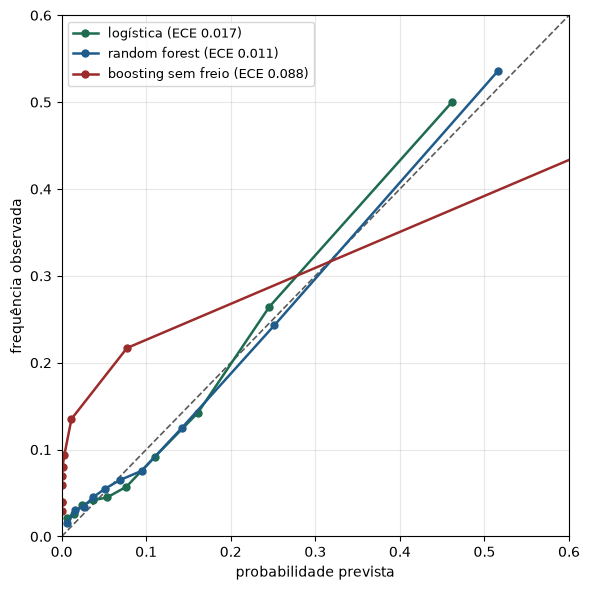

In [6]:
modelos = {"logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
           "random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1),
           "boosting sem freio": HistGradientBoostingClassifier(max_iter=500, learning_rate=0.3, random_state=0)}
prev = {nome: m.fit(X_tr, y_tr).predict_proba(X_te)[:, 1] for nome, m in modelos.items()}
print(pd.DataFrame({nome: resumo(y_te, p) for nome, p in prev.items()}).T.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color=CINZA, ls="--", lw=1.2)
for (nome, p), cor in zip(prev.items(), [VERDE, AZUL, VERMELHO]):
    d = diagrama(y_te, p)
    ax.plot(d["previsão média"], d["frequência observada"], marker="o", ms=5, lw=1.8, color=cor,
            label=f"{nome} (ECE {ece(y_te, p):.3f})")
ax.set_xlabel("probabilidade prevista"); ax.set_ylabel("frequência observada"); ax.legend(fontsize=9)
ax.set_xlim(0, 0.6); ax.set_ylim(0, 0.6)
plt.tight_layout(); plt.show()

**Por quê:** logística e floresta ordenam parecido; o boosting sem
freio perde AUC por sobreajuste e, além disso, tem o pior Brier e um ECE
cinco vezes maior: ele memorizou o treino e devolve probabilidades
extremas para segurados de risco moderado. A logística, apesar de não
modelar o pico de risco dos 22 anos, sai perto da diagonal, porque
otimiza a log loss. A random forest com folhas de 5 sai igualmente bem.
Para precificar hoje, sem recalibrar, a resposta é a floresta ou a
logística, e nunca o boosting sem freio, mesmo que a AUC dele fosse a
maior. O detalhe importante: a decisão usa a tabela inteira, Brier e
ECE incluídos, não só a coluna da AUC.

---
## Exercício 3 🟡 — O que a reamostragem fez com o preço

Um analista, preocupado com o desbalanceamento (9% de sinistros),
reequilibrou o treino para 50/50 por undersampling e treinou um
boosting com freio (`learning_rate=0.05, max_iter=200`). (a) Mostre o
que aconteceu com a média das probabilidades e com o ECE no teste.
(b) Corrija pela fórmula de priori. (c) Corrija com Platt scaling
ajustado na base de calibração (`CalibratedClassifierCV` com
`FrozenEstimator`). Compare as duas correções e diga qual usar.

In [7]:
# --- sua resposta ---

### Gabarito 3

In [8]:
pos, neg = np.where(y_tr == 1)[0], np.where(y_tr == 0)[0]
idx_bal = np.concatenate([pos, rng.choice(neg, len(pos), replace=False)])
pi_t, pi = 0.5, y_tr.mean()
freio = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=0).fit(X_tr[idx_bal], y_tr[idx_bal])
p_bal = freio.predict_proba(X_te)[:, 1]

r_pos, r_neg = pi / pi_t, (1 - pi) / (1 - pi_t)
p_priori = p_bal * r_pos / (p_bal * r_pos + (1 - p_bal) * r_neg)
platt = CalibratedClassifierCV(FrozenEstimator(freio), method="sigmoid").fit(X_cal, y_cal)
p_platt = platt.predict_proba(X_te)[:, 1]

for nome, p in [("(a) reequilibrado", p_bal), ("(b) correção de priori", p_priori), ("(c) Platt na calibração", p_platt)]:
    r = resumo(y_te, p)
    print(f"{nome:>24s}: média de p̂ {p.mean():.3f} (real {y_te.mean():.3f}) | Brier {r['Brier']:.4f} | "
          f"ECE {r['ECE']:.4f} | AUC {r['AUC']:.4f}")

       (a) reequilibrado: média de p̂ 0.370 (real 0.123) | Brier 0.1774 | ECE 0.2472 | AUC 0.8072
  (b) correção de priori: média de p̂ 0.143 (real 0.123) | Brier 0.0904 | ECE 0.0383 | AUC 0.8072
 (c) Platt na calibração: média de p̂ 0.126 (real 0.123) | Brier 0.0860 | ECE 0.0079 | AUC 0.8072


**Por quê:** treinado em 50/50, o modelo devolve uma média de $\hat{p}$
perto de 0,37 para uma carteira com 12% de sinistros: todo prêmio
sairia três vezes maior. A correção de priori, que não usa dado nenhum
além das duas prevalências, traz a média de volta e corta o ECE por
várias vezes; o Platt ajustado em 4.000 casos chega a um resultado
parecido ou um pouco melhor, porque além de corrigir a priori ele
também corrige a forma. Qual usar: a correção de priori é gratuita e
deve ser aplicada **sempre** que houver reamostragem; o Platt vale a
pena quando existe base de calibração, e conserta o que sobrou. As duas
não competem. E a AUC não se mexeu em nenhuma das três linhas, o que é
a prova de que a reamostragem nunca foi um problema de ordenação.

---
## Exercício 4 🟡 — Platt ou isotônica, com quantos dados

Para o boosting sem freio do exercício 2, calibre com Platt e com
isotônica usando bases de calibração de 100, 500 e 4.000 casos (sorteie
subconjuntos de `X_cal`, 10 sementes cada) e meça o Brier médio no
teste. Inclua a linha "sem calibrar". Qual método para cada tamanho?

In [9]:
# --- sua resposta ---

### Gabarito 4

In [10]:
sem_freio = modelos["boosting sem freio"]
linhas = []
for n in [100, 500, 4000]:
    for sem in range(10):
        idx = np.random.default_rng(sem).choice(len(y_cal), n, replace=False)
        for metodo in ["sigmoid", "isotonic"]:
            cal = CalibratedClassifierCV(FrozenEstimator(sem_freio), method=metodo).fit(X_cal[idx], y_cal[idx])
            linhas.append({"n": n, "método": metodo, "Brier": brier_score_loss(y_te, cal.predict_proba(X_te)[:, 1])})
tabela = pd.DataFrame(linhas).groupby(["n", "método"])["Brier"].agg(["mean", "std"]).unstack("método")
print(tabela.round(4).to_string())
print(f"\nsem calibrar: Brier {brier_score_loss(y_te, prev['boosting sem freio']):.4f} | oráculo: {brier_score_loss(y_te, p_te):.4f}")

           mean              std        
método isotonic sigmoid isotonic sigmoid
n                                       
100      0.0964  0.0920   0.0029  0.0020
500      0.0920  0.0906   0.0008  0.0003
4000     0.0904  0.0903   0.0000  0.0000

sem calibrar: Brier 0.1034 | oráculo: 0.0803


**Por quê:** com 100 casos (uma dúzia de sinistros!), a isotônica
constrói uma escada sobre uma dúzia de positivos: ainda melhora o
modelo, mas fica atrás de Platt e com mais variância entre sementes.
Com 500 os dois ajudam e o Platt ainda é mais estável. Com 4.000 os dois
convergem. A regra de bolso do notebook 2 (Platt até ~1.000, isotônica
acima) se confirma, com um agravante para bases desbalanceadas: o que
conta é o número de **positivos** na base de calibração, não o total de
linhas.

---
## Exercício 5 🔴 — O preço da descalibração

A seguradora vai precificar 30.000 apólices (a base de teste) com prêmio
$= \hat{p} \times \text{SEVERIDADE} \times (1 + \text{MARGEM})$. Compare
o boosting sem freio cru com a sua versão calibrada (isotônica na base
de calibração) e com o oráculo, em três medidas: (a) prêmio total
arrecadado contra custo total dos sinistros (a **sinistralidade**,
custo/prêmio; o alvo, com margem de 25%, é 0,80); (b) a sinistralidade
**por decil de prêmio cobrado**, do decil mais barato ao mais caro;
(c) a fração de apólices cujo prêmio ficou mais de 30% acima ou abaixo
do prêmio justo (o do oráculo). O que a calibração conserta e o que ela
não conserta? Depois escreva o protocolo de calibração para o time de
precificação: em que base calibrar, com que método, o que monitorar e
quando recalibrar.

In [11]:
# --- sua resposta ---

### Gabarito 5

In [12]:
iso = CalibratedClassifierCV(FrozenEstimator(sem_freio), method="isotonic").fit(X_cal, y_cal)
p_iso = iso.predict_proba(X_te)[:, 1]
custo_real = y_te * SEVERIDADE
premio_justo = p_te * SEVERIDADE * (1 + MARGEM)
precos = {"cru": prev["boosting sem freio"], "calibrado": p_iso, "oráculo": p_te}

print("(a) agregado")
for nome, p in precos.items():
    premio = p * SEVERIDADE * (1 + MARGEM)
    print(f"  {nome:>10s}: prêmio total R$ {premio.sum() / 1e6:5.1f} mi | sinistralidade {custo_real.sum() / premio.sum():.2f}")

print("\n(b) sinistralidade por decil de prêmio cobrado (1 = mais barato)")
def por_decil(p):
    decil = pd.qcut(pd.Series(p).rank(method="first"), 10, labels=False) + 1    # rank evita empates da isotônica
    premio = pd.Series(p * SEVERIDADE * (1 + MARGEM))
    return pd.Series(custo_real).groupby(decil).sum() / premio.groupby(decil).sum()

decis = pd.DataFrame({nome: por_decil(p) for nome, p in precos.items()}).T
print(decis.round(2).to_string(float_format=lambda v: f"{v:8.2f}" if v < 100 else f"{v:8.0f}"))

print("\n(c) apólices com prêmio fora de ±30% do justo")
for nome, p in precos.items():
    erro_rel = p * SEVERIDADE * (1 + MARGEM) / premio_justo - 1
    print(f"  {nome:>10s}: {np.mean(np.abs(erro_rel) > 0.30):5.1%}")

(a) agregado
         cru: prêmio total R$  25.7 mi | sinistralidade 1.29
   calibrado: prêmio total R$  42.6 mi | sinistralidade 0.78
     oráculo: prêmio total R$  41.7 mi | sinistralidade 0.79

(b) sinistralidade por decil de prêmio cobrado (1 = mais barato)
                1        2        3        4        5        6        7        8        9        10
cru          25052     3027      700      337      139    59.45    23.37     9.27     2.24     0.55
calibrado     1.37     0.60     0.59     0.72     0.93     0.84     0.75     0.71     0.85     0.76
oráculo       0.81     0.84     0.84     0.79     0.68     0.84     0.79     0.78     0.79     0.80

(c) apólices com prêmio fora de ±30% do justo
         cru: 95.3%
   calibrado: 73.5%
     oráculo:  0.0%


**Como avaliar sua resposta:** o modelo cru arrecada muito menos do que
os sinistros custam (sinistralidade acima de 1: prejuízo), porque a
superconfiança empurra a maioria das apólices para perto de zero. E a
tabela por decil mostra o estrago em detalhe: nos decis baratos a
sinistralidade é enorme (cobra quase nada de quem dá sinistro), nos
caros é minúscula (cobra demais de quem quase nunca dá; esses clientes
vão embora, e a seleção adversa piora o ano seguinte). O calibrado
fecha o agregado e deixa os decis na faixa de 0,6 a 0,9 (o primeiro,
com pouquíssimos sinistros, é o mais ruidoso), contra 0,7 a 0,85 do
oráculo: em cada faixa de preço, o prêmio paga os sinistros com uma
margem perto da certa. Isso é o que calibração conserta.

O que ela não conserta aparece em (c): mesmo calibrado, boa parte das
apólices individuais fica longe do prêmio justo, porque o modelo não
tem resolução para separar um risco de 2% de um de 5%. Calibração
ajusta a escala; a resolução (o termo da decomposição de Murphy do
exercício 1) só melhora com um modelo melhor ou features melhores.

O protocolo que uma boa resposta escreve: (1) três bases: treino,
calibração e teste, com a calibração **nunca** vinda do treino e com a
proporção real de sinistros; (2) isotônica se a base de calibração
tiver alguns milhares de casos e algumas centenas de positivos, Platt
se não; correção de priori antes de tudo se houve reamostragem;
(3) monitorar mensalmente a sinistralidade por decil e o Brier da safra
que já completou 12 meses, além da AUC; (4) recalibrar (barato) quando
os decis saírem da faixa e a AUC não; retreinar (caro) quando a AUC
também cair.

---
## Fechamento

- Brier = incerteza − resolução + confiabilidade. Resolução ruim pede
  modelo; confiabilidade ruim pede recalibração.
- A tabela inteira decide: AUC para ordenar, Brier e ECE para acreditar
  no número.
- Reamostragem infla a probabilidade; a correção de priori é gratuita e
  obrigatória, e Platt conserta o que sobra.
- Platt com poucos positivos, isotônica com muitos; conte positivos,
  não linhas.
- Quando a probabilidade é o preço, descalibrar é cobrar errado de cada
  cliente, e errar mais nos que podem ir embora.

→ Próximo módulo: **Otimização de Hiperparâmetros**.